# ConformalHydride — Master Pipeline
**Conformal certification of reversible metal hydrides (ML-HydPARK, n = 398)**

One clean end-to-end notebook. Upload the contents of `ConformalHydride_DATA.zip` as a Kaggle
Dataset, attach it as input, enable the GPU accelerator, and Run All (~30-40 min).
It regenerates every figure (F1-F8), every table (T1-T12), all model checkpoints, and packages
them into `ConformalHydride_MASTER_results.zip` with a machine-readable run report.

Sections: setup -> data audit -> features & screening pool -> exploratory figures ->
models (LightGBM + HyCAN ensembles) -> conformal interval comparison -> FDR-controlled
selection -> pool certification -> leave-one-source-out shift -> conditional-coverage
repairs -> feasibility / shift / anchor diagnostics -> report & archive.


In [1]:
# ============================================================================
# ConformalHydride — MASTER PIPELINE
# Conformal certification of reversible metal hydrides (ML-HydPARK, n = 398)
# Runs end-to-end from the ConformalHydride_DATA.zip Kaggle dataset and
# regenerates every figure (F1-F8), table (T1-T12) and checkpoint of the study.
# GPU recommended (Tesla T4 sufficient). Full run ~30-40 min. Set the
# environment variable CHY_FAST_DEV=1 only for smoke-testing the pipeline.
# ============================================================================
import os, re, io, sys, json, time, math, glob, zipfile, hashlib, warnings, platform, random
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
T0 = time.time(); TIMES = {}
def tick(name): TIMES[name] = round(time.time() - T0, 1); print(f"[t+{TIMES[name]:7.1f}s] {name}")
FAST_DEV = bool(int(os.environ.get("CHY_FAST_DEV", "0")))

class CFG:
    SEED = 42; ALPHA = 0.10
    SEEDS_LGBM  = int(os.environ.get("CHY_SEEDS", "3")) if FAST_DEV else 20     # LightGBM-only stability
    SEEDS_NN    = 2 if FAST_DEV else 5      # shared seeds for all cross-model work
    ENSEMBLE_K  = 2 if FAST_DEV else 5
    EPOCHS      = 10 if FAST_DEV else 200
    BATCH = 64; LR = 1e-3; WEIGHT_DECAY = 1e-4
    D_MODEL = 64; N_HEADS = 4; N_LAYERS = 2; DROPOUT = 0.10
    TRAIN_FRAC = 0.60; CALIB_FRAC = 0.20
    TARGETS = ["dH", "lnPeq"]
    DH_WINDOW = (25.0, 45.0); DH_PLAUS = (5.0, 120.0); DS_PLAUS = (60.0, 180.0)
    FDR_QS = [0.05, 0.10, 0.20, 0.33]; Q_MAIN = 0.20
    STABLE_MIN = 1 if FAST_DEV else 4
    LOSO_MAX_SOURCES = int(os.environ.get("CHY_LOSO", "25")) if FAST_DEV else None
    MONDRIAN_MIN = 20; N_JOBS = 4
CFG.SEEDS_SEL = CFG.SEEDS_NN   # alias used by the selection sections

random.seed(CFG.SEED); np.random.seed(CFG.SEED)
OUT = "conformalhydride_out"
for d in ["figures", "tables", "checkpoints"]: os.makedirs(os.path.join(OUT, d), exist_ok=True)
WONG = ["#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7, "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 6.2, "legend.frameon": False, "axes.linewidth": 0.8,
    "lines.linewidth": 1.0, "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "xtick.major.size": 3, "ytick.major.size": 3, "figure.dpi": 110, "savefig.dpi": 300,
    "pdf.fonttype": 42, "axes.spines.top": False, "axes.spines.right": False})
def panel(ax, letter, x=-0.16):
    ax.text(x, 1.05, letter, transform=ax.transAxes, fontsize=9, fontweight="bold", va="top", ha="left")
TLAB = {"dH": r"$\Delta H_{\mathrm{des}}$ (kJ (mol H$_2$)$^{-1}$)",
        "lnPeq": r"$\ln P_{\mathrm{eq}}$(25 \u00b0C)"}
def save_fig(fig, name):
    for ext in ("png", "pdf"): fig.savefig(os.path.join(OUT, "figures", f"{name}.{ext}"), bbox_inches="tight")
    print(f"  saved figures/{name}.png|pdf")
def save_table(d, name, index=False):
    d.to_csv(os.path.join(OUT, "tables", f"{name}.csv"), index=index); print(f"  saved tables/{name}.csv ({len(d)} rows)")
REPORT = {"headline": [], "env": {}, "fast_dev": FAST_DEV}
def headline(s): REPORT["headline"].append(s); print("HEADLINE:", s)

import lightgbm as lgb, sklearn
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score
from scipy.stats import norm as scipy_norm
import torch, torch.nn as nn
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU_NAME = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "none (CPU fallback)"
REPORT["env"] = {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
                 "sklearn": sklearn.__version__, "lightgbm": lgb.__version__, "torch": torch.__version__,
                 "device": DEVICE, "gpu": GPU_NAME, "fast_dev": FAST_DEV}
print(json.dumps(REPORT["env"], indent=2))
if DEVICE != "cuda": print("!! WARNING: no GPU detected — enable the Kaggle GPU accelerator for the full run.")
tick("setup")


{
  "python": "3.12.13",
  "numpy": "2.0.2",
  "pandas": "2.3.3",
  "sklearn": "1.6.1",
  "lightgbm": "4.6.0",
  "torch": "2.10.0+cu128",
  "device": "cuda",
  "gpu": "Tesla T4",
  "fast_dev": false
}
[t+   11.2s] setup


In [2]:
# ===================== PART 1 — locate, load, audit =====================
def find_data_file(fname):
    cands  = [fname, os.path.join("hydpark", fname), os.path.join("chy_data", fname)]
    cands += sorted(glob.glob(f"/kaggle/input/*/{fname}")) + sorted(glob.glob(f"/kaggle/input/*/*/{fname}"))
    cands += [os.path.join("/mnt/user-data/uploads", fname)]
    for c in cands:
        if os.path.exists(c): return c
    # last resort: pull from the source repo (works on Kaggle with internet ON)
    import urllib.request
    os.makedirs("chy_data", exist_ok=True); dst = os.path.join("chy_data", fname)
    for sub in ("ml_data", "experiments"):
        try:
            urllib.request.urlretrieve(
                f"https://raw.githubusercontent.com/mwitman1/HEAhydrideML/main/{sub}/{fname}", dst)
            print(f"  downloaded {fname} from source repo ({sub}/)"); return dst
        except Exception:
            continue
    raise FileNotFoundError(f"{fname}: not found locally and not downloadable. "
                            f"Attach the ConformalHydride_DATA dataset (v2, which bundles it).")

PATH_MAIN = find_data_file("HYDPARK_ML_ready.csv")
PATH_POOL = find_data_file("rHEA_allpredictions_final.csv")
print("data:", PATH_MAIN)

df = pd.read_csv(PATH_MAIN)
df = df.rename(columns={"Heat_of_Formation_kJperMolH2": "dH",
                        "Entropy_of_Formation_kJperMolH2perK": "dS",
                        "LnEquilibrium_Pressure_25C": "lnPeq",
                        "Hydrogen_Weight_Percent": "wtpct",
                        "Material_Class": "mclass",
                        "Composition_Formula": "formula",
                        "Author_Year": "source"})
assert df["formula"].nunique() == len(df), "unexpected duplicate compositions"
N = len(df); CLASSES = df["mclass"].value_counts().index.tolist()
print(f"n = {N} unique compositions | classes: " +
      ", ".join(f"{c}:{(df.mclass==c).sum()}" for c in CLASSES))
print(f"literature sources: {df['source'].nunique()}")

# --- unit / consistency audit: reconstruct ln Peq(25 C) from dH, dS via van 't Hoff ---
R = 8.314462618; T25 = 298.15
lnPeq_recon = -df["dH"] * 1000.0 / (R * T25) + df["dS"] / R
vh_maxdiff = float(np.max(np.abs(lnPeq_recon - df["lnPeq"])))
print(f"van 't Hoff reconstruction max |diff| = {vh_maxdiff:.2e}  "
      f"(rounding-level: confirms dS is in J/(mol H2 K) despite the kJ header, and lnPeq is DERIVED from dH,dS)")
assert vh_maxdiff < 0.05, "lnPeq inconsistent with dH,dS beyond rounding — investigate before modelling"

# --- physical plausibility flags (paper-facing data-quality audit) ---
df["flag_dH"] = ~df["dH"].between(*CFG.DH_PLAUS)
df["flag_dS"] = ~df["dS"].between(*CFG.DS_PLAUS)
df["flag_any"] = df["flag_dH"] | df["flag_dS"]
df["in_window"] = df["dH"].between(*CFG.DH_WINDOW)
Peq25_atm = np.exp(df["lnPeq"])
df["in_Pwindow"] = (Peq25_atm >= 0.1) & (Peq25_atm <= 10.0)

t1 = pd.DataFrame({
    "quantity": ["n compositions", "n classes", "n literature sources",
                 f"dH outside {CFG.DH_PLAUS} kJ/mol H2", f"dS outside {CFG.DS_PLAUS} J/(mol H2 K)",
                 "any implausibility flag",
                 f"in reversible dH window {CFG.DH_WINDOW}", "Peq(25 C) in [0.1, 10] atm"],
    "value": [N, df.mclass.nunique(), df["source"].nunique(),
              int(df.flag_dH.sum()), int(df.flag_dS.sum()), int(df.flag_any.sum()),
              int(df.in_window.sum()), int(df.in_Pwindow.sum())]})
save_table(t1, "T1_data_audit")
print(t1.to_string(index=False))
headline(f"data audit: {int(df.flag_any.sum())}/{N} rows carry an implausible-thermodynamics flag "
         f"(dH outside {CFG.DH_PLAUS} or dS outside {CFG.DS_PLAUS}); {int(df.in_window.sum())} in the "
         f"{CFG.DH_WINDOW} kJ/mol H2 reversible window")
per_class = df.groupby("mclass").agg(n=("dH","size"), dH_mean=("dH","mean"), dH_std=("dH","std"),
                                     flagged=("flag_any","sum"), in_window=("in_window","sum")).round(2)
save_table(per_class.reset_index(), "T1b_per_class")
tick("PART 1 audit done")


  downloaded HYDPARK_ML_ready.csv from source repo (ml_data/)
  downloaded rHEA_allpredictions_final.csv from source repo (ml_data/)
data: chy_data/HYDPARK_ML_ready.csv
n = 398 unique compositions | classes: AB2:120, AB5:106, MIC:52, SS:45, AB:33, Mg:32, A2B:10
literature sources: 194
van 't Hoff reconstruction max |diff| = 4.64e-03  (rounding-level: confirms dS is in J/(mol H2 K) despite the kJ header, and lnPeq is DERIVED from dH,dS)
  saved tables/T1_data_audit.csv (8 rows)
                             quantity  value
                       n compositions    398
                            n classes      7
                 n literature sources    194
    dH outside (5.0, 120.0) kJ/mol H2     10
dS outside (60.0, 180.0) J/(mol H2 K)     19
              any implausibility flag     26
 in reversible dH window (25.0, 45.0)    242
           Peq(25 C) in [0.1, 10] atm    214
HEADLINE: data audit: 26/398 rows carry an implausible-thermodynamics flag (dH outside (5.0, 120.0) or dS outside

In [3]:
# ===================== PART 2 — features and composition encoding =====================
i0, i1 = df.columns.get_loc("NComp"), df.columns.get_loc("MeanIonicChar")
FEATURES = list(df.columns[i0:i1 + 1])                      # Magpie block (complete)
MP_STRUCT = ["energy_per_atom","formation_energy_per_atom","nsites","density","volume","volume_ps","empty_volume_ps"]
mp_missing = int(df[MP_STRUCT].isna().any(axis=1).sum())
print(f"Magpie feature block: {len(FEATURES)} columns; "
      f"MP structure block EXCLUDED (missing for {mp_missing}/{N} rows)")
X_TAB = df[FEATURES].to_numpy(dtype=np.float64)
assert not np.isnan(X_TAB).any(), "NaN in tabular features"

# --- composition parser (handles one level of parentheses, e.g. LaFe(CuNi)2) ---
TOK = re.compile(r"([A-Z][a-z]?)(\d*\.?\d*)")
PAR = re.compile(r"\(([^()]*)\)(\d*\.?\d*)")
def _flat(s):
    d, pos = {}, 0
    for m in TOK.finditer(s):
        if m.start() != pos: raise ValueError(f"cannot parse '{s}'")
        pos = m.end()
        d[m.group(1)] = d.get(m.group(1), 0.0) + (float(m.group(2)) if m.group(2) else 1.0)
    if pos != len(s): raise ValueError(f"cannot parse '{s}'")
    return d
def parse_formula(s):
    s = str(s).strip().replace(" ", "")
    while "(" in s:
        m = PAR.search(s)
        if not m: raise ValueError(f"unbalanced parentheses in '{s}'")
        inner = _flat(m.group(1)); mult = float(m.group(2)) if m.group(2) else 1.0
        s = s[:m.start()] + "".join(f"{e}{c*mult:.6g}" for e, c in inner.items()) + s[m.end():]
    d = _flat(s); tot = sum(d.values())
    return {e: c / tot for e, c in d.items()}

# unit tests — fail loudly, never silently
t = parse_formula("LaNi5");            assert abs(t["La"] - 1/6) < 1e-9 and abs(t["Ni"] - 5/6) < 1e-9
t = parse_formula("LaFe(CuNi)2");      assert abs(t["Cu"] - 2/6) < 1e-9 and abs(t["La"] - 1/6) < 1e-9
t = parse_formula("Mg14(TiAl4)3");     assert abs(t["Al"] - 12/29) < 1e-9 and abs(t["Mg"] - 14/29) < 1e-9
comps = [parse_formula(f) for f in df["formula"]]
print(f"parsed {len(comps)}/{N} formulas, 0 failures")

VOCAB = sorted({e for c in comps for e in c})
E2I = {e: i + 1 for i, e in enumerate(VOCAB)}               # 0 = padding
MAXL = max(len(c) for c in comps)
print(f"element vocabulary: {len(VOCAB)} | max elements per composition: {MAXL}")
E_ARR = np.zeros((N, MAXL), dtype=np.int64)
F_ARR = np.zeros((N, MAXL), dtype=np.float32)
for i, c in enumerate(comps):
    for j, (e, f) in enumerate(sorted(c.items(), key=lambda kv: -kv[1])):
        E_ARR[i, j] = E2I[e]; F_ARR[i, j] = f
M_ARR = (E_ARR > 0)
Y = {"dH": df["dH"].to_numpy(np.float64), "lnPeq": df["lnPeq"].to_numpy(np.float64)}
CLS = df["mclass"].to_numpy()
tick("PART 2 features done")


Magpie feature block: 145 columns; MP structure block EXCLUDED (missing for 302/398 rows)
parsed 398/398 formulas, 0 failures
element vocabulary: 50 | max elements per composition: 7
[t+   11.6s] PART 2 features done


In [4]:
# ===================== PART 1b — HEA screening pool =====================
PATH_POOL = find_data_file("rHEA_allpredictions_final.csv")
pool = pd.read_csv(PATH_POOL).rename(columns={"dH": "dH_witman", "dS": "dS_witman", "lnPeqo": "lnPeq_witman"})
pool = pool.drop_duplicates(subset="Composition").reset_index(drop=True)
pool_comp_raw = pool["Composition"].tolist()
pool_parsed, pool_oov = [], []
for c in pool_comp_raw:
    d = parse_formula(c)
    (pool_oov if any(e not in E2I for e in d) else pool_parsed).append((c, d))
oov_els = sorted({e for _, d in [(c, parse_formula(c)) for c in pool_comp_raw] for e in d if e not in E2I})
print(f"pool: {len(pool)} unique HEA candidates | screenable (in-vocab): {len(pool_parsed)} | "
      f"excluded for out-of-vocabulary element(s) {oov_els}: {len(pool_oov)}")
headline(f"pool: {len(pool_parsed)}/{len(pool)} candidates screenable; {len(pool_oov)} excluded "
         f"(contain {oov_els}, absent from the 50-element training vocabulary) — stated limitation")
POOL_OK = pd.DataFrame({"Composition": [c for c, _ in pool_parsed]}).merge(pool, on="Composition", how="left")
MP_ = len(pool_parsed)
E_P = np.zeros((MP_, MAXL), dtype=np.int64); F_P = np.zeros((MP_, MAXL), dtype=np.float32)
for i, (_, d) in enumerate(pool_parsed):
    for j, (e, f) in enumerate(sorted(d.items(), key=lambda kv: -kv[1])):
        E_P[i, j] = E2I[e]; F_P[i, j] = f
M_P = (E_P > 0)
n_wit_window = int(POOL_OK["dH_witman"].between(*CFG.DH_WINDOW).sum())
print(f"Witman point predictions in the {CFG.DH_WINDOW} window (screenable subset): {n_wit_window}/{MP_}")
tick("PART 1b pool")


pool: 672 unique HEA candidates | screenable (in-vocab): 336 | excluded for out-of-vocabulary element(s) ['Ta']: 336
HEADLINE: pool: 336/672 candidates screenable; 336 excluded (contain ['Ta'], absent from the 50-element training vocabulary) — stated limitation
Witman point predictions in the (25.0, 45.0) window (screenable subset): 217/336
[t+   11.7s] PART 1b pool


  saved figures/F1_targets_by_class.png|pdf


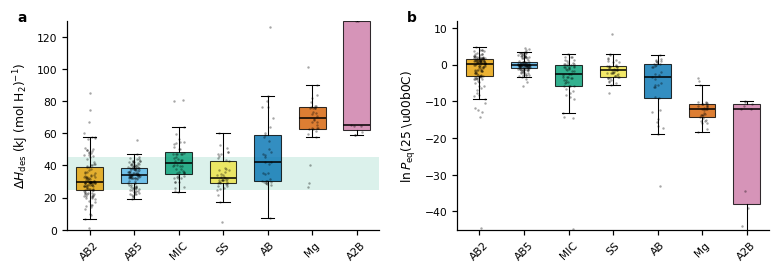

  saved figures/F2_vant_hoff_map.png|pdf


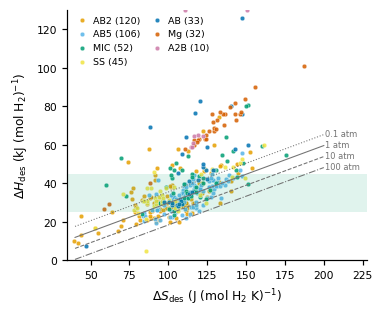

[t+   14.6s] exploratory figures


In [5]:
# ===================== exploratory figures (F1, F2) =====================
CPAL = {c: WONG[(i + 1) % len(WONG)] for i, c in enumerate(CLASSES)}

# F1 — target distributions by material class (panels a, b)
fig, axes = plt.subplots(1, 2, figsize=(7.1, 2.5))
for ax, tgt, letter in zip(axes, ["dH", "lnPeq"], "ab"):
    data = [df.loc[df.mclass == c, tgt].values for c in CLASSES]
    bp = ax.boxplot(data, labels=CLASSES, showfliers=False, patch_artist=True, widths=0.6,
                    medianprops=dict(color="black", lw=1), boxprops=dict(lw=0.7),
                    whiskerprops=dict(lw=0.7), capprops=dict(lw=0.7))
    for patch, c in zip(bp["boxes"], CLASSES): patch.set_facecolor(CPAL[c]); patch.set_alpha(0.8)
    rngj = np.random.RandomState(0)
    for i, c in enumerate(CLASSES):
        yv = df.loc[df.mclass == c, tgt].values
        ax.scatter(np.full(len(yv), i + 1) + rngj.uniform(-0.13, 0.13, len(yv)), yv,
                   s=2.5, color="black", alpha=0.35, linewidths=0, zorder=3)
    ax.set_ylabel(TLAB[tgt]); ax.tick_params(axis="x", rotation=45); panel(ax, letter)
if not FAST_DEV: axes[0].set_ylim(0, 130); axes[1].set_ylim(-45, 12)
axes[0].axhspan(*CFG.DH_WINDOW, color=WONG[3], alpha=0.14, lw=0)
fig.tight_layout(w_pad=2.0); save_fig(fig, "F1_targets_by_class"); plt.show()

# F2 — van 't Hoff map with iso-Peq(25 C) lines and the reversible window
fig, ax = plt.subplots(figsize=(3.5, 2.9))
for c in CLASSES:
    s = df.mclass == c
    ax.scatter(df.loc[s, "dS"], df.loc[s, "dH"], s=9, color=CPAL[c], label=f"{c} ({s.sum()})",
               alpha=0.85, edgecolors="white", linewidths=0.25)
ds_line = np.linspace(40, 200, 50)
for P, ls in [(0.1, ":"), (1.0, "-"), (10.0, "--"), (100.0, "-.")]:
    ax.plot(ds_line, T25 * (ds_line - R * np.log(P)) / 1000.0, ls, color="0.45", lw=0.7)
    ax.annotate(f"{P:g} atm", (201, T25 * (200 - R * np.log(P)) / 1000.0 - 1.0), fontsize=5.5, color="0.45")
ax.axhspan(*CFG.DH_WINDOW, color=WONG[3], alpha=0.12, lw=0)
ax.set_xlim(35, 228); ax.set_ylim(0, 130)
ax.set_xlabel(r"$\Delta S_{\mathrm{des}}$ (J (mol H$_2$ K)$^{-1}$)")
ax.set_ylabel(TLAB["dH"])
ax.legend(ncol=2, handletextpad=0.15, columnspacing=0.7, loc="upper left", borderaxespad=0.2)
fig.tight_layout(); save_fig(fig, "F2_vant_hoff_map"); plt.show()
tick("exploratory figures")


In [6]:
# ===================== PART 4 — models (LightGBM CPU + HyCAN transformer GPU) =====================
def make_split(seed):
    idx = np.arange(N)
    tr, tmp = train_test_split(idx, train_size=CFG.TRAIN_FRAC, random_state=seed, stratify=CLS)
    rel = CFG.CALIB_FRAC / (1.0 - CFG.TRAIN_FRAC)
    ca, te = train_test_split(tmp, train_size=rel, random_state=seed, stratify=CLS[tmp])
    return tr, ca, te

LGBM_PARAMS = dict(n_estimators=600, learning_rate=0.05, num_leaves=31, min_child_samples=5,
                   subsample=0.9, subsample_freq=1, colsample_bytree=0.9, n_jobs=CFG.N_JOBS, verbose=-1)

def fit_lgbm_point(tr, y, seed):
    m = lgb.LGBMRegressor(random_state=seed, **LGBM_PARAMS); m.fit(X_TAB[tr], y[tr]); return m
def fit_lgbm_quant(tr, y, seed, q):
    m = lgb.LGBMRegressor(objective="quantile", alpha=q, random_state=seed, **LGBM_PARAMS)
    m.fit(X_TAB[tr], y[tr]); return m

# ---- HyCAN: Hydride Composition Attention Network (CrabNet-style, self-contained) ----
class HyCAN(nn.Module):
    def __init__(self, vocab, d=CFG.D_MODEL, heads=CFG.N_HEADS, layers=CFG.N_LAYERS, drop=CFG.DROPOUT):
        super().__init__()
        self.emb = nn.Embedding(vocab + 1, d, padding_idx=0)
        self.fproj = nn.Sequential(nn.Linear(2, d), nn.GELU(), nn.Linear(d, d))
        enc = nn.TransformerEncoderLayer(d_model=d, nhead=heads, dim_feedforward=4 * d,
                                         dropout=drop, activation="gelu",
                                         batch_first=True, norm_first=True)
        self.enc = nn.TransformerEncoder(enc, layers)
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, d), nn.GELU(),
                                  nn.Dropout(drop), nn.Linear(d, 1))
    def forward(self, E, F, M):
        f2 = torch.stack([F, torch.log(F.clamp_min(1e-6))], dim=-1)
        x = self.emb(E) + self.fproj(f2)
        x = self.enc(x, src_key_padding_mask=~M)
        x = (x * M.unsqueeze(-1)).sum(1) / M.sum(1, keepdim=True).clamp_min(1)
        return self.head(x).squeeze(-1)

E_T = torch.from_numpy(E_ARR); F_T = torch.from_numpy(F_ARR); M_T = torch.from_numpy(M_ARR)

def train_hycan(tr, y, seed):
    torch.manual_seed(seed); np.random.seed(seed % (2**31)); random.seed(seed)
    mu, sd = float(y[tr].mean()), float(y[tr].std() + 1e-9)
    yt = torch.tensor((y - mu) / sd, dtype=torch.float32)
    model = HyCAN(len(VOCAB)).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG.EPOCHS)
    idx = np.array(tr); loss_fn = nn.MSELoss()
    model.train()
    for ep in range(CFG.EPOCHS):
        np.random.shuffle(idx)
        for b0 in range(0, len(idx), CFG.BATCH):
            b = idx[b0:b0 + CFG.BATCH]
            Eb, Fb, Mb = E_T[b].to(DEVICE), F_T[b].to(DEVICE), M_T[b].to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(Eb, Fb, Mb), yt[b].to(DEVICE))
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        sch.step()
    model.eval()
    with torch.no_grad():
        preds = []
        for b0 in range(0, N, 256):
            sl = slice(b0, min(b0 + 256, N))
            preds.append(model(E_T[sl].to(DEVICE), F_T[sl].to(DEVICE), M_T[sl].to(DEVICE)).cpu().numpy())
    return np.concatenate(preds) * sd + mu

# ---- run everything; PRED[(target, model, seed)] holds full-length prediction vectors ----
PRED, SPLITS = {}, {}
QLO, QHI = CFG.ALPHA / 2, 1 - CFG.ALPHA / 2
t_lgbm = time.time()
for tgt in CFG.TARGETS:
    y = Y[tgt]
    for seed in range(CFG.SEEDS_LGBM):
        tr, ca, te = SPLITS.setdefault(seed, make_split(seed))
        PRED[(tgt, "lgbm", seed)] = fit_lgbm_point(tr, y, seed).predict(X_TAB)
        PRED[(tgt, "lgbm_qlo", seed)] = fit_lgbm_quant(tr, y, seed, QLO).predict(X_TAB)
        PRED[(tgt, "lgbm_qhi", seed)] = fit_lgbm_quant(tr, y, seed, QHI).predict(X_TAB)
print(f"LightGBM: {CFG.SEEDS_LGBM} seeds x {len(CFG.TARGETS)} targets in {time.time()-t_lgbm:.0f}s")

t_nn = time.time()
for tgt in CFG.TARGETS:
    y = Y[tgt]
    for seed in range(CFG.SEEDS_NN):
        tr, ca, te = SPLITS[seed]
        members = np.stack([train_hycan(tr, y, 1000 * seed + k) for k in range(CFG.ENSEMBLE_K)])
        PRED[(tgt, "nn_mu", seed)] = members.mean(0)
        PRED[(tgt, "nn_sd", seed)] = members.std(0, ddof=1) if CFG.ENSEMBLE_K > 1 else np.full(N, 1e-3)
        print(f"  HyCAN {tgt} seed {seed}: K={CFG.ENSEMBLE_K} done  [t+{time.time()-t_nn:.0f}s]")
print(f"HyCAN ensembles: {time.time()-t_nn:.0f}s on {DEVICE} ({GPU_NAME})")

# accuracy table on test folds (common seeds only, so models are compared on identical splits)
rows = []
for tgt in CFG.TARGETS:
    y = Y[tgt]
    for mdl, key in [("LightGBM", "lgbm"), ("HyCAN-ens", "nn_mu")]:
        maes, rmses, r2s = [], [], []
        for seed in range(CFG.SEEDS_NN):
            te = SPLITS[seed][2]; yh = PRED[(tgt, key, seed)][te]
            maes.append(mean_absolute_error(y[te], yh))
            rmses.append(float(np.sqrt(np.mean((y[te] - yh) ** 2))))
            r2s.append(r2_score(y[te], yh))
        rows.append(dict(target=tgt, model=mdl,
                         MAE=f"{np.mean(maes):.3f}+/-{np.std(maes):.3f}",
                         RMSE=f"{np.mean(rmses):.3f}+/-{np.std(rmses):.3f}",
                         R2=f"{np.mean(r2s):.3f}+/-{np.std(r2s):.3f}"))
t2 = pd.DataFrame(rows); save_table(t2, "T2_accuracy"); print(t2.to_string(index=False))

# checkpoint every prediction vector (offline reuse for Stage 2: selection, shift, FDR)
ck = {f"{tgt}|{m}|{s}": PRED[(tgt, m, s)] for (tgt, m, s) in PRED}
ck["_splits"] = np.array([np.concatenate([[seed], [len(SPLITS[seed][0])], SPLITS[seed][0],
                                          [len(SPLITS[seed][1])], SPLITS[seed][1], SPLITS[seed][2]])
                          for seed in SPLITS], dtype=object)
np.savez_compressed(os.path.join(OUT, "checkpoints", "predictions.npz"),
                    **{k: v for k, v in ck.items() if k != "_splits"})
with open(os.path.join(OUT, "checkpoints", "splits.json"), "w") as f:
    json.dump({str(s): [SPLITS[s][0].tolist(), SPLITS[s][1].tolist(), SPLITS[s][2].tolist()]
               for s in SPLITS}, f)
df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")]).to_csv(
    os.path.join(OUT, "checkpoints", "dataset_audited.csv"), index=False)
tick("PART 4 models done")


LightGBM: 20 seeds x 2 targets in 65s
  HyCAN dH seed 0: K=5 done  [t+36s]
  HyCAN dH seed 1: K=5 done  [t+66s]
  HyCAN dH seed 2: K=5 done  [t+96s]
  HyCAN dH seed 3: K=5 done  [t+125s]
  HyCAN dH seed 4: K=5 done  [t+155s]
  HyCAN lnPeq seed 0: K=5 done  [t+185s]
  HyCAN lnPeq seed 1: K=5 done  [t+214s]
  HyCAN lnPeq seed 2: K=5 done  [t+244s]
  HyCAN lnPeq seed 3: K=5 done  [t+274s]
  HyCAN lnPeq seed 4: K=5 done  [t+303s]
HyCAN ensembles: 303s on cuda (Tesla T4)
  saved tables/T2_accuracy.csv (4 rows)
target     model           MAE           RMSE            R2
    dH  LightGBM 8.632+/-0.777 20.552+/-7.766 0.573+/-0.147
    dH HyCAN-ens 9.904+/-1.064 22.820+/-8.581 0.498+/-0.102
 lnPeq  LightGBM 2.398+/-0.325  6.397+/-2.667 0.633+/-0.166
 lnPeq HyCAN-ens 2.903+/-0.312  7.712+/-2.429 0.473+/-0.112
[t+  383.6s] PART 4 models done


  saved tables/T3_marginal_common_seeds.csv (12 rows)
  saved tables/T3b_marginal_lgbm_stability.csv (6 rows)
  saved tables/T4_conditional_by_class.csv (84 rows)
target        method      coverage           width
    dH  SplitCP-LGBM 0.910+/-0.015  36.173+/-4.326
    dH Mondrian-LGBM 0.915+/-0.018 63.138+/-48.093
    dH      CQR-LGBM 0.915+/-0.024  38.848+/-5.028
    dH    SplitCP-NN 0.907+/-0.020  39.211+/-5.217
    dH     NormCP-NN 0.897+/-0.068 72.237+/-13.297
    dH DeepEns-naive 0.320+/-0.049  10.021+/-1.166
 lnPeq  SplitCP-LGBM 0.915+/-0.018  10.478+/-1.515
 lnPeq Mondrian-LGBM 0.922+/-0.022 18.861+/-14.282
 lnPeq      CQR-LGBM 0.903+/-0.037  10.573+/-0.711
 lnPeq    SplitCP-NN 0.893+/-0.023  10.779+/-1.424
 lnPeq     NormCP-NN 0.897+/-0.009  19.158+/-0.802
 lnPeq DeepEns-naive 0.348+/-0.048   3.319+/-0.440
  saved tables/T5_mondrian_viability.csv (7 rows)
mclass  n_total  calib_mean  viable
   AB2      120        24.0    True
   AB5      106        21.5    True
   MIC       52 

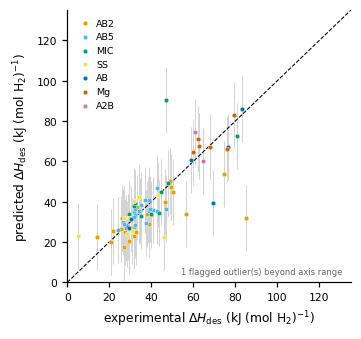

  saved figures/F4_conditional_coverage.png|pdf


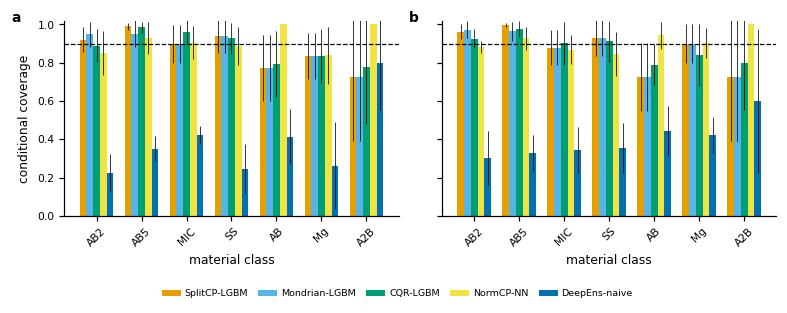

  saved figures/F5_calibration_curve.png|pdf


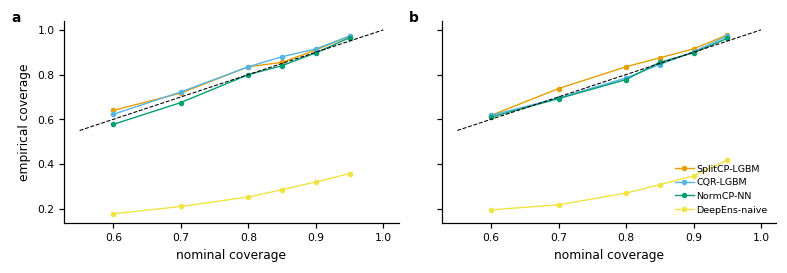

[t+  386.3s] PART 5 conformal done


In [7]:
# ===================== PART 5 — conformal prediction: 6 methods, marginal + conditional =====================
def qfinite(scores, alpha):
    n = len(scores)
    q = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
    return float(np.quantile(scores, q, method="higher"))

def intervals(tgt, seed, method, alpha=CFG.ALPHA):
    y = Y[tgt]; tr, ca, te = SPLITS[seed]
    if method == "SplitCP-LGBM":
        yh = PRED[(tgt, "lgbm", seed)]; q = qfinite(np.abs(y[ca] - yh[ca]), alpha)
        return yh[te] - q, yh[te] + q
    if method == "Mondrian-LGBM":
        yh = PRED[(tgt, "lgbm", seed)]; s_ca = np.abs(y[ca] - yh[ca])
        qg = qfinite(s_ca, alpha); lo = np.empty(len(te)); hi = np.empty(len(te))
        for c in CLASSES:
            mca, mte = CLS[ca] == c, CLS[te] == c
            qc = qfinite(s_ca[mca], alpha) if mca.sum() >= CFG.MONDRIAN_MIN else qg
            lo[mte], hi[mte] = yh[te][mte] - qc, yh[te][mte] + qc
        return lo, hi
    if method == "CQR-LGBM":
        ql, qh = PRED[(tgt, "lgbm_qlo", seed)], PRED[(tgt, "lgbm_qhi", seed)]
        s = np.maximum(ql[ca] - y[ca], y[ca] - qh[ca]); q = qfinite(s, alpha)
        return ql[te] - q, qh[te] + q
    if method == "SplitCP-NN":
        mu = PRED[(tgt, "nn_mu", seed)]; q = qfinite(np.abs(y[ca] - mu[ca]), alpha)
        return mu[te] - q, mu[te] + q
    if method == "NormCP-NN":
        mu, sd = PRED[(tgt, "nn_mu", seed)], np.maximum(PRED[(tgt, "nn_sd", seed)], 1e-3)
        q = qfinite(np.abs(y[ca] - mu[ca]) / sd[ca], alpha)
        return mu[te] - q * sd[te], mu[te] + q * sd[te]
    if method == "DeepEns-naive":
        mu, sd = PRED[(tgt, "nn_mu", seed)], PRED[(tgt, "nn_sd", seed)]
        z = scipy_norm.ppf(1 - alpha / 2)
        return mu[te] - z * sd[te], mu[te] + z * sd[te]
    raise ValueError(method)

METHODS = ["SplitCP-LGBM", "Mondrian-LGBM", "CQR-LGBM", "SplitCP-NN", "NormCP-NN", "DeepEns-naive"]
def nseeds(m): return CFG.SEEDS_LGBM if m.endswith("LGBM") else CFG.SEEDS_NN

# ---- T3 marginal coverage/width (common seeds), T3b LGBM stability (all seeds) ----
rows3, rows3b, rows4 = [], [], []
for tgt in CFG.TARGETS:
    y = Y[tgt]
    for m in METHODS:
        covs, wids = [], []
        for seed in range(CFG.SEEDS_NN):
            te = SPLITS[seed][2]; lo, hi = intervals(tgt, seed, m)
            covs.append(float(np.mean((y[te] >= lo) & (y[te] <= hi))))
            wids.append(float(np.mean(hi - lo)))
        rows3.append(dict(target=tgt, method=m,
                          coverage=f"{np.mean(covs):.3f}+/-{np.std(covs):.3f}",
                          width=f"{np.mean(wids):.3f}+/-{np.std(wids):.3f}",
                          cov_num=np.mean(covs), wid_num=np.mean(wids)))
        # per-class conditional coverage
        for c in CLASSES:
            ccov, cn = [], []
            for seed in range(nseeds(m)):
                te = SPLITS[seed][2]; lo, hi = intervals(tgt, seed, m)
                mk = CLS[te] == c
                if mk.sum() == 0: continue
                ccov.append(float(np.mean((y[te][mk] >= lo[mk]) & (y[te][mk] <= hi[mk]))))
                cn.append(int(mk.sum()))
            rows4.append(dict(target=tgt, method=m, mclass=c, n_test_mean=np.mean(cn),
                              coverage=np.mean(ccov), cov_sd=np.std(ccov)))
    for m in ["SplitCP-LGBM", "Mondrian-LGBM", "CQR-LGBM"]:
        covs, wids = [], []
        for seed in range(CFG.SEEDS_LGBM):
            te = SPLITS[seed][2]; lo, hi = intervals(tgt, seed, m)
            covs.append(float(np.mean((y[te] >= lo) & (y[te] <= hi)))); wids.append(float(np.mean(hi - lo)))
        rows3b.append(dict(target=tgt, method=m, seeds=CFG.SEEDS_LGBM,
                           coverage=f"{np.mean(covs):.3f}+/-{np.std(covs):.3f}",
                           width=f"{np.mean(wids):.3f}+/-{np.std(wids):.3f}"))
t3 = pd.DataFrame(rows3); save_table(t3.drop(columns=["cov_num","wid_num"]), "T3_marginal_common_seeds")
t3b = pd.DataFrame(rows3b); save_table(t3b, "T3b_marginal_lgbm_stability")
t4 = pd.DataFrame(rows4); save_table(t4, "T4_conditional_by_class")
print(t3.drop(columns=["cov_num","wid_num"]).to_string(index=False))

# ---- T5 Mondrian stratum viability ----
rows5 = []
for c in CLASSES:
    ns = [int((CLS[SPLITS[s][1]] == c).sum()) for s in range(CFG.SEEDS_LGBM)]
    rows5.append(dict(mclass=c, n_total=int((CLS == c).sum()),
                      calib_mean=np.mean(ns), viable=all(n >= CFG.MONDRIAN_MIN for n in ns)))
t5 = pd.DataFrame(rows5); save_table(t5, "T5_mondrian_viability"); print(t5.to_string(index=False))

# ---- headlines ----
for tgt in CFG.TARGETS:
    sub = t4[(t4.target == tgt)]
    for m in ["SplitCP-LGBM", "Mondrian-LGBM", "DeepEns-naive", "NormCP-NN"]:
        w = sub[sub.method == m].sort_values("coverage")
        if len(w):
            headline(f"{tgt} | {m}: worst-class coverage {w.iloc[0].coverage:.3f} ({w.iloc[0].mclass}) "
                     f"at nominal {1-CFG.ALPHA:.2f}")
de = t3[(t3.method == "DeepEns-naive")]
headline("DeepEns-naive marginal coverage: " +
         ", ".join(f"{r.target}={r.cov_num:.3f}" for r in de.itertuples()))

# ---- F3 parity with intervals (dH, LGBM SplitCP, seed 0) ----
tgt, seed = "dH", 0; y = Y[tgt]; te = SPLITS[seed][2]
lo, hi = intervals(tgt, seed, "SplitCP-LGBM"); yh = PRED[(tgt, "lgbm", seed)][te]
fig, ax = plt.subplots(figsize=(3.3, 3.1))
ax.errorbar(y[te], yh, yerr=[yh - lo, hi - yh], fmt="none", ecolor="0.82", elinewidth=0.6, zorder=1)
for c in CLASSES:
    mk = CLS[te] == c
    ax.scatter(y[te][mk], yh[mk], s=9, color=CPAL[c], label=c, edgecolors="white", linewidths=0.25, zorder=3)
lim = [0, CFG.DH_PLAUS[1] + 15]
n_out = int(((y[te] > lim[1]) | (yh > lim[1])).sum())
ax.plot(lim, lim, "k--", lw=0.7); ax.set_xlim(lim); ax.set_ylim(lim)
if n_out:
    ax.annotate(f"{n_out} flagged outlier(s) beyond axis range", (0.97, 0.03),
                xycoords="axes fraction", ha="right", fontsize=5.5, color="0.4")
ax.set_xlabel("experimental " + TLAB["dH"]); ax.set_ylabel("predicted " + TLAB["dH"])
ax.legend(loc="upper left", handletextpad=0.15)
fig.tight_layout(); save_fig(fig, "F3_parity_intervals"); plt.show()

# ---- F4 conditional coverage by class (panels a, b) ----
show_m = ["SplitCP-LGBM", "Mondrian-LGBM", "CQR-LGBM", "NormCP-NN", "DeepEns-naive"]
fig, axes = plt.subplots(1, 2, figsize=(7.1, 2.55), sharey=True)
w = 0.15
for ax, tgt, letter in zip(axes, CFG.TARGETS, "ab"):
    for j, m in enumerate(show_m):
        sub = t4[(t4.target == tgt) & (t4.method == m)].set_index("mclass").reindex(CLASSES)
        ax.bar(np.arange(len(CLASSES)) + (j - 2) * w, sub.coverage, width=w, color=WONG[j + 1],
               label=m, yerr=sub.cov_sd, error_kw=dict(lw=0.5, capsize=0))
    ax.axhline(1 - CFG.ALPHA, color="black", ls="--", lw=0.8)
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45)
    ax.set_ylim(0, 1.02); ax.set_xlabel("material class")
    panel(ax, letter, x=-0.10 if letter == "b" else -0.16)
axes[0].set_ylabel("conditional coverage")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.10), columnspacing=1.1, handletextpad=0.4)
fig.tight_layout(w_pad=1.5); save_fig(fig, "F4_conditional_coverage"); plt.show()

# ---- F5 empirical vs nominal coverage (panels a, b) ----
alphas = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40]
fig, axes = plt.subplots(1, 2, figsize=(7.1, 2.5), sharey=True)
for ax, tgt, letter in zip(axes, CFG.TARGETS, "ab"):
    y = Y[tgt]
    for j, m in enumerate(["SplitCP-LGBM", "CQR-LGBM", "NormCP-NN", "DeepEns-naive"]):
        emp = []
        for a in alphas:
            cs = []
            for seed in range(CFG.SEEDS_NN):
                te = SPLITS[seed][2]; lo, hi = intervals(tgt, seed, m, alpha=a)
                cs.append(float(np.mean((y[te] >= lo) & (y[te] <= hi))))
            emp.append(np.mean(cs))
        ax.plot([1 - a for a in alphas], emp, "o-", color=WONG[j + 1], label=m, ms=2.6, lw=0.9)
    ax.plot([0.55, 1.0], [0.55, 1.0], "k--", lw=0.7)
    ax.set_xlabel("nominal coverage"); panel(ax, letter, x=-0.10 if letter == "b" else -0.16)
axes[0].set_ylabel("empirical coverage"); axes[1].legend(loc="lower right", handletextpad=0.3)
fig.tight_layout(w_pad=1.5); save_fig(fig, "F5_calibration_curve"); plt.show()
tick("PART 5 conformal done")


In [8]:
# ===================== PART 2 — selection machinery + LGBM test-fold evaluation =====================
A_W, B_W = CFG.DH_WINDOW
y_dH = Y["dH"]; Z_WIN = ((y_dH >= A_W) & (y_dH <= B_W)).astype(int)
FLAG = df["flag_any"].to_numpy(bool)

def bh_select(p, q):
    m = len(p); o = np.argsort(p); thr = q * np.arange(1, m + 1) / m
    ok = np.nonzero(np.sort(p) <= thr)[0]; k = (ok[-1] + 1) if len(ok) else 0
    sel = np.zeros(m, bool); sel[o[:k]] = True; return sel

def p_iut_window(yhat_ca, y_ca, yhat_q):
    # IUT of two one-sided conformal p-values (Jin & Candes-style, monotone score V = y - yhat)
    r = y_ca - yhat_ca; n = len(r)
    p_le = np.array([(1 + (r <= (A_W - v)).sum()) / (n + 1) for v in yhat_q])  # null: Y <= A
    p_ge = np.array([(1 + (r >= (B_W - v)).sum()) / (n + 1) for v in yhat_q])  # null: Y >= B
    return np.maximum(p_le, p_ge)

def p_clf_window(s_ca, z_ca, s_q):
    # conformal p-value for the null "not in window", score = P(in-window | x)
    s0 = s_ca[z_ca == 0]; n0 = len(s0)
    return np.array([(1 + (s0 >= v).sum()) / (n0 + 1) for v in s_q])

def eval_sel(sel, y_true_sub):
    ti = (y_true_sub >= A_W) & (y_true_sub <= B_W)
    fdp = (sel & ~ti).sum() / sel.sum() if sel.sum() else np.nan
    power = (sel & ti).sum() / max(ti.sum(), 1)
    return fdp, power, int(sel.sum())

CLF_PARAMS = dict(LGBM_PARAMS); CLF_PARAMS["n_estimators"] = 400

LG_REG, LG_CLF = {}, {}
LG_REG_NF, LG_CLF_NF = {}, {}
for seed in range(CFG.SEEDS_SEL):
    tr, ca, te = SPLITS[seed]
    LG_REG[seed] = PRED[("dH", "lgbm", seed)]
    LG_CLF[seed] = lgb.LGBMClassifier(random_state=seed, **CLF_PARAMS).fit(X_TAB[tr], Z_WIN[tr]).predict_proba(X_TAB)[:, 1]
    trn = tr[~FLAG[tr]]  # flag-excluded variants: retrain and evaluate on unflagged rows only
    LG_REG_NF[seed] = lgb.LGBMRegressor(random_state=seed, **LGBM_PARAMS).fit(X_TAB[trn], y_dH[trn]).predict(X_TAB)
    LG_CLF_NF[seed] = lgb.LGBMClassifier(random_state=seed, **CLF_PARAMS).fit(X_TAB[trn], Z_WIN[trn]).predict_proba(X_TAB)[:, 1]
print(f"LightGBM selection models fitted for {CFG.SEEDS_SEL} seeds")

def selection_pvalues(variant, seed):
    tr, ca, te = SPLITS[seed]
    if variant.endswith("noflag"): ca, te = ca[~FLAG[ca]], te[~FLAG[te]]
    if variant == "Naive-point":       return None, te
    if variant == "IUT-LGBM":          return p_iut_window(LG_REG[seed][ca], y_dH[ca], LG_REG[seed][te]), te
    if variant == "IUT-LGBM-noflag":   return p_iut_window(LG_REG_NF[seed][ca], y_dH[ca], LG_REG_NF[seed][te]), te
    if variant == "CLF-LGBM":          return p_clf_window(LG_CLF[seed][ca], Z_WIN[ca], LG_CLF[seed][te]), te
    if variant == "CLF-LGBM-noflag":   return p_clf_window(LG_CLF_NF[seed][ca], Z_WIN[ca], LG_CLF_NF[seed][te]), te
    raise ValueError(variant)

VARIANTS = ["Naive-point", "IUT-LGBM", "IUT-LGBM-noflag", "CLF-LGBM", "CLF-LGBM-noflag"]
rows6 = []
for v in VARIANTS:
    for q in CFG.FDR_QS:
        fs, ps, ns = [], [], []
        for seed in range(CFG.SEEDS_SEL):
            p, te = selection_pvalues(v, seed)
            if v == "Naive-point":
                yh = LG_REG[seed][te]; sel = (yh >= A_W) & (yh <= B_W)
            else:
                sel = bh_select(p, q)
            f, pw, n_s = eval_sel(sel, y_dH[te])
            if not np.isnan(f): fs.append(f)
            ps.append(pw); ns.append(n_s)
        rows6.append(dict(variant=v, q=q, FDR=np.mean(fs) if fs else np.nan, FDR_sd=np.std(fs) if fs else np.nan,
                          power=np.mean(ps), power_sd=np.std(ps), n_sel=np.mean(ns)))
        if v == "Naive-point": break  # q-independent
t6 = pd.DataFrame(rows6); save_table(t6.round(3), "T6_selection_testfold")
print(t6.round(3).to_string(index=False))
nv = t6[t6.variant == "Naive-point"].iloc[0]
headline(f"naive point-in-window selection: FDR {nv.FDR:.3f} (uncontrolled), power {nv.power:.3f}")
iu = t6[(t6.variant == "IUT-LGBM") & (t6.q == CFG.Q_MAIN)].iloc[0]
headline(f"certification wall: IUT regression selection certifies {iu.n_sel:.1f} candidates at q={CFG.Q_MAIN} "
         f"(window width {B_W-A_W:g} kJ/mol H2 < residual tail spread)")
cl = t6[(t6.variant == "CLF-LGBM") & (t6.q == CFG.Q_MAIN)].iloc[0]
headline(f"classification-score selection restores discovery: FDR {cl.FDR:.3f} <= q={CFG.Q_MAIN}, "
         f"power {cl.power:.3f}, ~{cl.n_sel:.0f} certified per split")
tick("PART 2 selection test-fold")


LightGBM selection models fitted for 5 seeds
  saved tables/T6_selection_testfold.csv (17 rows)
        variant    q   FDR  FDR_sd  power  power_sd  n_sel
    Naive-point 0.05 0.230   0.041  0.886     0.049   53.8
       IUT-LGBM 0.05   NaN     NaN  0.000     0.000    0.0
       IUT-LGBM 0.10   NaN     NaN  0.000     0.000    0.0
       IUT-LGBM 0.20   NaN     NaN  0.000     0.000    0.0
       IUT-LGBM 0.33   NaN     NaN  0.000     0.000    0.0
IUT-LGBM-noflag 0.05   NaN     NaN  0.000     0.000    0.0
IUT-LGBM-noflag 0.10   NaN     NaN  0.000     0.000    0.0
IUT-LGBM-noflag 0.20   NaN     NaN  0.000     0.000    0.0
IUT-LGBM-noflag 0.33   NaN     NaN  0.000     0.000    0.0
       CLF-LGBM 0.05   NaN     NaN  0.000     0.000    0.0
       CLF-LGBM 0.10 0.138   0.000  0.122     0.244    5.8
       CLF-LGBM 0.20 0.136   0.075  0.466     0.268   25.8
       CLF-LGBM 0.33 0.121   0.085  0.565     0.224   31.2
CLF-LGBM-noflag 0.05   NaN     NaN  0.000     0.000    0.0
CLF-LGBM-noflag 0.1

  HyCAN seed 0: reg+clf ensembles done  [t+59s]
  HyCAN seed 1: reg+clf ensembles done  [t+118s]
  HyCAN seed 2: reg+clf ensembles done  [t+177s]
  HyCAN seed 3: reg+clf ensembles done  [t+236s]
  HyCAN seed 4: reg+clf ensembles done  [t+295s]
HyCAN: 5 seeds x 5 members x 2 heads on cuda (Tesla T4) in 295s
  saved tables/T6_selection_testfold.csv (21 rows)
HEADLINE: CLF-HyCAN (composition-only) test-fold selection: FDR 0.111, power 0.096 at q=0.2 — this is the head that certifies the HEA pool
  saved figures/F6_selection_fdr_power.png|pdf


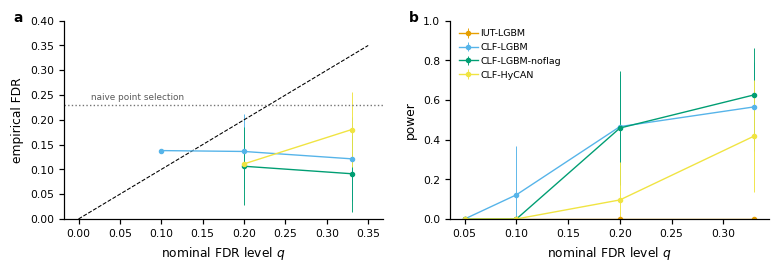

[t+  690.1s] PART 3 HyCAN + selection eval


In [9]:
# ===================== PART 3 — HyCAN regression + classification ensembles (GPU) =====================
E_ALL = torch.from_numpy(np.vstack([E_ARR, E_P])); F_ALL = torch.from_numpy(np.vstack([F_ARR, F_P]))
M_ALL = torch.from_numpy(np.vstack([M_ARR, M_P])); N_ALL = N + MP_

def _predict_all(model):
    model.eval(); out = []
    with torch.no_grad():
        for b0 in range(0, N_ALL, 256):
            sl = slice(b0, min(b0 + 256, N_ALL))
            out.append(model(E_ALL[sl].to(DEVICE), F_ALL[sl].to(DEVICE), M_ALL[sl].to(DEVICE)).cpu().numpy())
    return np.concatenate(out)

def train_hycan2(tr, target, kind, seed):
    torch.manual_seed(seed); np.random.seed(seed % (2**31)); random.seed(seed)
    model = HyCAN(len(VOCAB)).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG.EPOCHS)
    if kind == "reg":
        mu, sd = float(target[tr].mean()), float(target[tr].std() + 1e-9)
        yt = torch.tensor((target - mu) / sd, dtype=torch.float32); loss_fn = nn.MSELoss()
    else:
        yt = torch.tensor(target, dtype=torch.float32); loss_fn = nn.BCEWithLogitsLoss()
    idx = np.array(tr); model.train()
    for ep in range(CFG.EPOCHS):
        np.random.shuffle(idx)
        for b0 in range(0, len(idx), CFG.BATCH):
            b = idx[b0:b0 + CFG.BATCH]
            opt.zero_grad()
            out = model(E_ALL[b].to(DEVICE), F_ALL[b].to(DEVICE), M_ALL[b].to(DEVICE))
            loss = loss_fn(out, yt[b].to(DEVICE))
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        sch.step()
    raw = _predict_all(model)
    if kind == "reg": return raw * sd + mu
    return 1.0 / (1.0 + np.exp(-raw))

NN_REG_MU, NN_REG_SD, NN_CLF = {}, {}, {}
t_nn = time.time()
for seed in range(CFG.SEEDS_SEL):
    tr, ca, te = SPLITS[seed]
    reg = np.stack([train_hycan2(tr, y_dH, "reg", 1000 * seed + k) for k in range(CFG.ENSEMBLE_K)])
    NN_REG_MU[seed], NN_REG_SD[seed] = reg.mean(0), (reg.std(0, ddof=1) if CFG.ENSEMBLE_K > 1 else np.full(N_ALL, 1e-3))
    clf = np.stack([train_hycan2(tr, Z_WIN, "clf", 5000 * seed + k) for k in range(CFG.ENSEMBLE_K)])
    NN_CLF[seed] = clf.mean(0)
    print(f"  HyCAN seed {seed}: reg+clf ensembles done  [t+{time.time()-t_nn:.0f}s]")
print(f"HyCAN: {CFG.SEEDS_SEL} seeds x {CFG.ENSEMBLE_K} members x 2 heads on {DEVICE} ({GPU_NAME}) "
      f"in {time.time()-t_nn:.0f}s")


# HyCAN classification-score selection on test folds -> append to T6
rows6b = []
for q in CFG.FDR_QS:
    fs, ps, ns = [], [], []
    for seed in range(CFG.SEEDS_SEL):
        tr, ca, te = SPLITS[seed]
        p = p_clf_window(NN_CLF[seed][ca], Z_WIN[ca], NN_CLF[seed][te])
        f, pw, n_s = eval_sel(bh_select(p, q), y_dH[te])
        if not np.isnan(f): fs.append(f)
        ps.append(pw); ns.append(n_s)
    rows6b.append(dict(variant="CLF-HyCAN", q=q, FDR=np.mean(fs) if fs else np.nan,
                       FDR_sd=np.std(fs) if fs else np.nan, power=np.mean(ps), power_sd=np.std(ps),
                       n_sel=np.mean(ns)))
t6 = pd.concat([t6, pd.DataFrame(rows6b)], ignore_index=True)
save_table(t6.round(3), "T6_selection_testfold")
ch = t6[(t6.variant == "CLF-HyCAN") & (t6.q == CFG.Q_MAIN)].iloc[0]
headline(f"CLF-HyCAN (composition-only) test-fold selection: FDR {ch.FDR:.3f}, power {ch.power:.3f} at q={CFG.Q_MAIN} "
         f"— this is the head that certifies the HEA pool")

# F6 — FDR and power vs nominal q (panels a, b)
fig, axes = plt.subplots(1, 2, figsize=(7.1, 2.5))
show = ["IUT-LGBM", "CLF-LGBM", "CLF-LGBM-noflag", "CLF-HyCAN"]
for j, v in enumerate(show):
    sub = t6[t6.variant == v].sort_values("q")
    axes[0].errorbar(sub.q, sub.FDR, yerr=sub.FDR_sd, fmt="o-", color=WONG[j + 1], label=v,
                     ms=2.6, lw=0.9, elinewidth=0.6, capsize=0)
    axes[1].errorbar(sub.q, sub.power, yerr=sub.power_sd, fmt="o-", color=WONG[j + 1], label=v,
                     ms=2.6, lw=0.9, elinewidth=0.6, capsize=0)
axes[0].plot([0, 0.35], [0, 0.35], "k--", lw=0.7)
nv_fdr = float(t6[t6.variant == "Naive-point"].FDR.iloc[0])
axes[0].axhline(nv_fdr, color="0.45", ls=":", lw=0.9)
axes[0].annotate("naive point selection", (0.015, nv_fdr + 0.010), fontsize=5.8, color="0.35")
axes[0].set_xlabel("nominal FDR level $q$"); axes[0].set_ylabel("empirical FDR"); axes[0].set_ylim(0, 0.4)
axes[1].set_xlabel("nominal FDR level $q$"); axes[1].set_ylabel("power"); axes[1].set_ylim(0, 1)
axes[1].legend(loc="upper left", handletextpad=0.3)
panel(axes[0], "a"); panel(axes[1], "b", x=-0.13)
fig.tight_layout(w_pad=2.0); save_fig(fig, "F6_selection_fdr_power"); plt.show()
tick("PART 3 HyCAN + selection eval")


  saved tables/T7_pool_certification.csv (336 rows)
HEADLINE: one-sided pool shortlist 'desorbing' at q=0.2: 0 candidates stable across >= 4/5 seeds
HEADLINE: one-sided pool shortlist 'stable' at q=0.2: 229 candidates stable across >= 4/5 seeds
  saved tables/T7_pool_certification.csv (336 rows)
HEADLINE: HEA pool: 0 candidates STABLY certified (>= 4/5 seeds) into the reversible window at FDR q=0.2; 0 selected in at least one seed; Witman point-in-window count was 217/336 — certification is the scarce resource, ranking is not
            Composition  dH_witman  dS_witman  lnPeq_witman  HyCAN_dH_mean  p_median  sel_q0.05  sel_q0.1  sel_q0.2  sel_q0.33  stable  onesided_desorbing_q0.2  onesided_stable_q0.2
    Al1 Zr1 Ti1 Mo1 Pd1  34.340156  90.018407     -3.701397      40.090000    0.0625          0         0         0          1   False                        0                     3
Al1 Zr1 Ti1 Mo1 Pd1 Nb1  34.201192  88.227694     -3.157137      46.150002    0.0625          0         

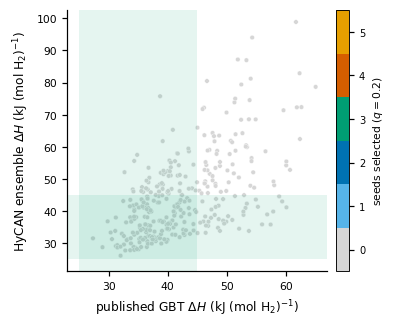

[t+  691.0s] PART 4 pool certification


In [10]:
# ===================== PART 4 — HEA pool certification (the discovery output) =====================
POOL_SEL = {q: np.zeros((CFG.SEEDS_SEL, MP_), bool) for q in CFG.FDR_QS}
POOL_P = np.zeros((CFG.SEEDS_SEL, MP_))
for seed in range(CFG.SEEDS_SEL):
    tr, ca, te = SPLITS[seed]
    s_pool = NN_CLF[seed][N:]                       # classifier prob on pool rows
    POOL_P[seed] = p_clf_window(NN_CLF[seed][ca], Z_WIN[ca], s_pool)
    for q in CFG.FDR_QS:
        POOL_SEL[q][seed] = bh_select(POOL_P[seed], q)

t7 = POOL_OK[["Composition", "dH_witman", "dS_witman", "lnPeq_witman"]].copy()
t7["HyCAN_dH_mean"] = np.mean([NN_REG_MU[s][N:] for s in range(CFG.SEEDS_SEL)], axis=0).round(2)
t7["p_median"] = np.median(POOL_P, axis=0).round(4)
for q in CFG.FDR_QS:
    t7[f"sel_q{q:g}"] = POOL_SEL[q].sum(0)
t7["stable"] = t7[f"sel_q{CFG.Q_MAIN:g}"] >= CFG.STABLE_MIN
t7 = t7.sort_values(["stable", f"sel_q{CFG.Q_MAIN:g}", "p_median"],
                    ascending=[False, False, True]).reset_index(drop=True)
save_table(t7, "T7_pool_certification")

# one-sided shortlists (aligned with the CPU Stage-2 thesis: two-sided certification may be infeasible,
# one-sided claims remain deliverable): "desorbing" H0: dH >= 45 rejected => dH < 45; "stable" H0: dH <= 25 rejected => dH > 25
def p_onesided_pool(seed, which):
    tr, ca, te = SPLITS[seed]
    yh = NN_REG_MU[seed]; r = y_dH[ca] - yh[ca]; n = len(r)
    yq = yh[N:]
    if which == "desorbing":   # null Y >= B_W
        return np.array([(1 + (r >= (B_W - v)).sum()) / (n + 1) for v in yq])
    return np.array([(1 + (r <= (A_W - v)).sum()) / (n + 1) for v in yq])  # null Y <= A_W
for which in ["desorbing", "stable"]:
    sel_ct = np.zeros(MP_, int)
    for seed in range(CFG.SEEDS_SEL):
        sel_ct += bh_select(p_onesided_pool(seed, which), CFG.Q_MAIN).astype(int)
    t7[f"onesided_{which}_q{CFG.Q_MAIN:g}"] = t7["Composition"].map(
        dict(zip(POOL_OK["Composition"], sel_ct)))
    headline(f"one-sided pool shortlist '{which}' at q={CFG.Q_MAIN}: "
             f"{int((sel_ct >= CFG.STABLE_MIN).sum())} candidates stable across >= {CFG.STABLE_MIN}/{CFG.SEEDS_SEL} seeds")
save_table(t7, "T7_pool_certification")
n_stable = int(t7["stable"].sum())
n_any = int((t7[f"sel_q{CFG.Q_MAIN:g}"] > 0).sum())
headline(f"HEA pool: {n_stable} candidates STABLY certified (>= {CFG.STABLE_MIN}/{CFG.SEEDS_SEL} seeds) into the "
         f"reversible window at FDR q={CFG.Q_MAIN}; {n_any} selected in at least one seed; "
         f"Witman point-in-window count was {int(POOL_OK['dH_witman'].between(*CFG.DH_WINDOW).sum())}/{MP_} "
         f"— certification is the scarce resource, ranking is not")
print(t7.head(15).to_string(index=False))

# F7 — selection map on the pool
fig, ax = plt.subplots(figsize=(3.6, 3.0))
nsel = t7.set_index("Composition").loc[POOL_OK["Composition"], f"sel_q{CFG.Q_MAIN:g}"].to_numpy()
cmap = matplotlib.colors.ListedColormap(
    ["#D6D6D6", WONG[2], WONG[5], WONG[3], WONG[6], WONG[1]][:CFG.SEEDS_SEL + 1])
sc = ax.scatter(POOL_OK["dH_witman"], np.mean([NN_REG_MU[s_][N:] for s_ in range(CFG.SEEDS_SEL)], axis=0),
                c=nsel, cmap=cmap, s=9, vmin=-0.5, vmax=CFG.SEEDS_SEL + 0.5,
                edgecolors="white", linewidths=0.25)
ax.axvspan(A_W, B_W, color=WONG[3], alpha=0.10, lw=0); ax.axhspan(A_W, B_W, color=WONG[3], alpha=0.10, lw=0)
cb = plt.colorbar(sc, ax=ax, ticks=range(CFG.SEEDS_SEL + 1), fraction=0.05, pad=0.03)
cb.set_label(f"seeds selected ($q={CFG.Q_MAIN:g}$)", fontsize=7)
cb.ax.tick_params(labelsize=6.5); cb.outline.set_linewidth(0.6)
ax.set_xlabel(r"published GBT $\Delta H$ (kJ (mol H$_2$)$^{-1}$)")
ax.set_ylabel(r"HyCAN ensemble $\Delta H$ (kJ (mol H$_2$)$^{-1}$)")
fig.tight_layout(); save_fig(fig, "F7_pool_selection_map"); plt.show()
tick("PART 4 pool certification")


  LOSO 1/194  [t+2s]
  LOSO 41/194  [t+77s]
  LOSO 81/194  [t+153s]
  LOSO 121/194  [t+230s]
  LOSO 161/194  [t+312s]
  saved tables/T8_loso_per_source.csv (388 rows)
  saved tables/T8b_loso_summary.csv (2 rows)
        mean_cov  weighted_cov  frac_sources_below_80
target                                               
dH         0.857         0.894                  0.160
lnPeq      0.867         0.902                  0.144
HEADLINE: LOSO shift (dH): sample-weighted coverage 0.894 under leave-one-source-out (nominal 0.90); 16% of sources below 0.80
HEADLINE: LOSO shift (lnPeq): sample-weighted coverage 0.902 under leave-one-source-out (nominal 0.90); 14% of sources below 0.80
  saved tables/T8c_loso_worst_sources_dH.csv (10 rows)
  saved figures/F8_loso_ecdf.png|pdf


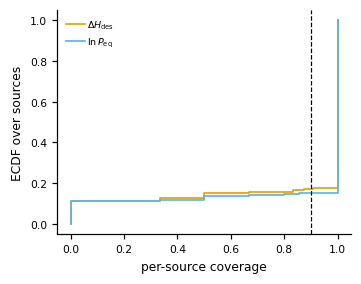

[t+ 1068.6s] PART 5 LOSO


In [11]:
# ===================== PART 5 — leave-one-source-out shift (LightGBM, CPU) =====================
SRC = df["source"].to_numpy()
sources = pd.Series(SRC).value_counts().index.tolist()
if CFG.LOSO_MAX_SOURCES: sources = sources[:CFG.LOSO_MAX_SOURCES]
rows8 = []
t_lo = time.time()
rng = np.random.RandomState(CFG.SEED)
for gi, g in enumerate(sources):
    hold = np.where(SRC == g)[0]; rest = np.where(SRC != g)[0]
    tr, ca = train_test_split(rest, train_size=0.8, random_state=gi)
    for tgt in CFG.TARGETS:
        yv = Y[tgt]
        m = lgb.LGBMRegressor(random_state=gi, **LGBM_PARAMS).fit(X_TAB[tr], yv[tr])
        res = np.abs(yv[ca] - m.predict(X_TAB[ca])); n = len(res)
        qh = float(np.quantile(res, min(1, np.ceil((n + 1) * (1 - CFG.ALPHA)) / n), method="higher"))
        yh = m.predict(X_TAB[hold])
        rows8.append(dict(source=g, n_held=len(hold), target=tgt,
                          coverage=float(np.mean(np.abs(yv[hold] - yh) <= qh))))
    if gi % 40 == 0: print(f"  LOSO {gi+1}/{len(sources)}  [t+{time.time()-t_lo:.0f}s]")
t8 = pd.DataFrame(rows8); save_table(t8, "T8_loso_per_source")
t8s = t8.groupby("target").agg(mean_cov=("coverage", "mean"),
                               weighted_cov=("coverage", lambda s: np.average(s, weights=t8.loc[s.index, "n_held"])),
                               frac_sources_below_80=("coverage", lambda s: float((s < 0.8).mean()))).round(3)
save_table(t8s.reset_index(), "T8b_loso_summary"); print(t8s.to_string())
for tgt in CFG.TARGETS:
    r = t8s.loc[tgt]
    headline(f"LOSO shift ({tgt}): sample-weighted coverage {r.weighted_cov:.3f} under leave-one-source-out "
             f"(nominal 0.90); {r.frac_sources_below_80*100:.0f}% of sources below 0.80")
worst = t8[t8.target == "dH"].sort_values("coverage").head(10)
save_table(worst, "T8c_loso_worst_sources_dH")

fig, ax = plt.subplots(figsize=(3.3, 2.6))
for j, tgt in enumerate(CFG.TARGETS):
    cv = np.sort(t8[t8.target == tgt].coverage.values)
    ax.step(cv, np.linspace(0, 1, len(cv)), where="post", color=WONG[j + 1],
            label=r"$\Delta H_{\mathrm{des}}$" if tgt == "dH" else r"$\ln P_{\mathrm{eq}}$", lw=1.1)
ax.axvline(0.90, color="black", ls="--", lw=0.8)
ax.set_xlabel("per-source coverage"); ax.set_ylabel("ECDF over sources")
ax.legend(loc="upper left", handletextpad=0.3)
fig.tight_layout(); save_fig(fig, "F8_loso_ecdf"); plt.show()
tick("PART 5 LOSO")


In [12]:
# ===================== PART 6 — conditional-coverage fixes =====================
MERGE3 = {c: ("AB2" if c == "AB2" else "AB5" if c == "AB5" else "other") for c in CLASSES}
CLS3 = np.array([MERGE3[c] for c in CLS])

def qfinite(scores, alpha=CFG.ALPHA):
    n = len(scores); q = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
    return float(np.quantile(scores, q, method="higher"))

rows9 = []
for seed in range(CFG.SEEDS_SEL):
    tr, ca, te = SPLITS[seed]
    yh = LG_REG[seed]; res_ca = np.abs(y_dH[ca] - yh[ca])
    variants = {}
    qg = qfinite(res_ca)
    variants["SplitCP"] = (yh[te] - qg, yh[te] + qg)
    lo = np.empty(len(te)); hi = np.empty(len(te))
    for c3 in ["AB2", "AB5", "other"]:
        mca, mte = CLS3[ca] == c3, CLS3[te] == c3
        qc = qfinite(res_ca[mca]) if mca.sum() >= CFG.MONDRIAN_MIN else qg
        lo[mte], hi[mte] = yh[te][mte] - qc, yh[te][mte] + qc
    variants["Mondrian-3strata"] = (lo, hi)
    can, ten = ca[~FLAG[ca]], te[~FLAG[te]]
    yhn = LG_REG_NF[seed]; qn = qfinite(np.abs(y_dH[can] - yhn[can]))
    variants["SplitCP-noflag"] = (yhn[ten] - qn, yhn[ten] + qn)
    mu, sd = NN_REG_MU[seed][:N], np.maximum(NN_REG_SD[seed][:N], 1e-3)
    qsc = qfinite(np.abs(y_dH[ca] - mu[ca]) / sd[ca])
    variants["NormCP-NN"] = (mu[te] - qsc * sd[te], mu[te] + qsc * sd[te])
    for name, (lo_, hi_) in variants.items():
        te_ = ten if name.endswith("noflag") else te
        cls_ = CLS[te_]
        for c in CLASSES:
            mk = cls_ == c
            if mk.sum() == 0: continue
            rows9.append(dict(seed=seed, variant=name, mclass=c,
                              coverage=float(np.mean((y_dH[te_][mk] >= lo_[mk]) & (y_dH[te_][mk] <= hi_[mk]))),
                              width=float(np.mean(hi_[mk] - lo_[mk]))))
t9 = (pd.DataFrame(rows9).groupby(["variant", "mclass"])
      .agg(coverage=("coverage", "mean"), cov_sd=("coverage", "std"), width=("width", "mean")).round(3).reset_index())
save_table(t9, "T9_conditional_fixes")
piv = t9.pivot(index="mclass", columns="variant", values="coverage").reindex(CLASSES)
print(piv.to_string())
for vname in ["SplitCP", "Mondrian-3strata", "SplitCP-noflag", "NormCP-NN"]:
    w = t9[t9.variant == vname].sort_values("coverage").iloc[0]
    headline(f"dH conditional fix | {vname}: worst-class {w.coverage:.3f} ({w.mclass}), mean width "
             f"{t9[t9.variant == vname].width.mean():.1f}")
tick("PART 6 conditional fixes")


  saved tables/T9_conditional_fixes.csv (28 rows)
variant  Mondrian-3strata  NormCP-NN  SplitCP  SplitCP-noflag
mclass                                                       
AB2                 0.925      0.850    0.908           0.913
AB5                 0.991      0.927    0.991           0.972
MIC                 0.980      0.904    0.905           1.000
SS                  1.000      0.889    0.889           0.908
AB                  0.910      1.000    0.762           0.817
Mg                  1.000      0.838    0.838           0.860
A2B                 0.900      1.000    0.900           1.000
HEADLINE: dH conditional fix | SplitCP: worst-class 0.762 (AB), mean width 36.2
HEADLINE: dH conditional fix | Mondrian-3strata: worst-class 0.900 (A2B), mean width 120.5
HEADLINE: dH conditional fix | SplitCP-noflag: worst-class 0.817 (AB), mean width 28.3
HEADLINE: dH conditional fix | NormCP-NN: worst-class 0.838 (Mg), mean width 93.0
[t+ 1068.7s] PART 6 conditional fixes


In [13]:
# ===================== Feasibility rule, shift diagnostics, experimental anchor =====================
# T10 — residual-span feasibility for two-sided window certification
rows10 = []
for q in [0.05, 0.10, 0.20]:
    sp = []
    for seed in range(CFG.SEEDS_NN):
        tr, ca, te = SPLITS[seed]
        r = y_dH[ca] - PRED[("dH", "lgbm", seed)][ca]
        sp.append(float(np.quantile(r, 1 - q) - np.quantile(r, q)))
    rows10.append(dict(q=q, span_mean=np.mean(sp), span_sd=np.std(sp),
                       window=CFG.DH_WINDOW[1] - CFG.DH_WINDOW[0],
                       feasible=np.mean(sp) < (CFG.DH_WINDOW[1] - CFG.DH_WINDOW[0])))
t10 = pd.DataFrame(rows10).round(2); save_table(t10, "T10_feasibility_spans"); print(t10.to_string(index=False))
r01 = t10[t10.q == 0.10].iloc[0]
headline(f"feasibility rule: central residual span {r01.span_mean:.1f}+/-{r01.span_sd:.1f} kJ/mol H2 at q=0.1 "
         f"vs window width {r01.window:.0f} — two-sided certification at the wall")

# T11 — pool exchangeability diagnostics (domain classifier on raw element fractions + ESS)
els_all = sorted(set(list(VOCAB)) | {e for _, d in pool_parsed for e in d} | set(oov_els))
def _fracvec(d): return [d.get(e, 0.0) for e in els_all]
Xdom = np.array([_fracvec(parse_formula(f)) for f in df["formula"]] +
                [_fracvec(parse_formula(c)) for c in pool_comp_raw])
zdom = np.r_[np.zeros(N), np.ones(len(pool_comp_raw))]
dom = lgb.LGBMClassifier(n_estimators=300, random_state=0, verbose=-1, n_jobs=CFG.N_JOBS)
pdom = cross_val_predict(dom, Xdom, zdom, cv=5, method="predict_proba")[:, 1]
auc = roc_auc_score(zdom, pdom)
w = pdom[:N] / (1 - pdom[:N] + 1e-12); ess = float((w.sum() ** 2) / (w ** 2).sum())
t11 = pd.DataFrame([dict(metric="domain classifier AUC (5-fold CV, element fractions)", value=round(auc, 3)),
                    dict(metric="effective calibration sample under likelihood-ratio weights", value=round(ess, 1)),
                    dict(metric="labelled set size", value=N)])
save_table(t11, "T11_shift_diagnostics"); print(t11.to_string(index=False))
headline(f"pool exchangeability: domain AUC {auc:.3f}, weighted-CP effective sample {ess:.1f}/{N}")

# T12 — the experimental anchor: measured HEA hydrides of this family
try:
    PATH_EXP = find_data_file("HEA_experiments_full.csv")
    anchor = pd.read_csv(PATH_EXP).rename(columns={"Composition_Formula": "Composition",
        "Heat_of_Formation_kJperMolH2": "dH_measured", "Entropy_of_Formation_kJperMolH2perK": "dS_measured",
        "LnEquilibrium_Pressure_25C": "lnPeq_measured"})
except FileNotFoundError:
    print("  anchor CSV unavailable — using the published values embedded below "
          "(Witman et al., Chem. Mater. 2021, experiments/HEA_experiments_full.csv)")
    anchor = pd.DataFrame({
        "Composition": ["NbTiVZrHf", "VTiZrNb", "NbTiV0.5ZrHf", "VTiAlCr", "VTiAlTaNb"],
        "dH_measured": [61.8, 67.6, 59.1, 42.7, 56.1],
        "dS_measured": [88.0, 90.3, 87.4, 88.4, 92.1],
        "lnPeq_measured": [-14.4, -16.4, -13.3, -6.6, -11.5]})
anchor["in_window"] = anchor["dH_measured"].between(*CFG.DH_WINDOW)
save_table(anchor.round(2), "T12_experimental_anchor"); print(anchor.round(2).to_string(index=False))
headline(f"experimental anchor: measured dH {anchor.dH_measured.min():.1f}-{anchor.dH_measured.max():.1f}, "
         f"mean {anchor.dH_measured.mean():.1f} kJ/mol H2; {int((~anchor.in_window).sum())}/{len(anchor)} outside the window")
tick("spine diagnostics")


  saved tables/T10_feasibility_spans.csv (3 rows)
   q  span_mean  span_sd  window  feasible
0.05      33.60     3.36    20.0     False
0.10      20.54     2.58    20.0     False
0.20      11.75     0.66    20.0      True
HEADLINE: feasibility rule: central residual span 20.5+/-2.6 kJ/mol H2 at q=0.1 vs window width 20 — two-sided certification at the wall
  saved tables/T11_shift_diagnostics.csv (3 rows)
                                                     metric  value
       domain classifier AUC (5-fold CV, element fractions)    1.0
effective calibration sample under likelihood-ratio weights    3.6
                                          labelled set size  398.0
HEADLINE: pool exchangeability: domain AUC 1.000, weighted-CP effective sample 3.6/398
  downloaded HEA_experiments_full.csv from source repo (experiments/)
  saved tables/T12_experimental_anchor.csv (5 rows)
 Composition  dH_measured  dS_measured  lnPeq_measured  in_window
   NbTiVZrHf         61.8         88.0          

In [14]:
# ===================== checkpoints, run report, single results archive =====================
np.savez_compressed(os.path.join(OUT, "checkpoints", "selection_predictions.npz"),
                    **{f"lgreg|{s}": LG_REG[s] for s in LG_REG},
                    **{f"lgclf|{s}": LG_CLF[s] for s in LG_CLF},
                    **{f"nnmu|{s}": NN_REG_MU[s] for s in NN_REG_MU},
                    **{f"nnsd|{s}": NN_REG_SD[s] for s in NN_REG_SD},
                    **{f"nnclf|{s}": NN_CLF[s] for s in NN_CLF}, pool_p=POOL_P)
POOL_OK.to_csv(os.path.join(OUT, "checkpoints", "pool_screenable.csv"), index=False)
REPORT["timings_s"] = TIMES
REPORT["config"] = {k: getattr(CFG, k) for k in dir(CFG) if not k.startswith("_")}
REPORT["data"] = dict(n=int(N), sources=int(df["source"].nunique()), flagged=int(df.flag_any.sum()),
                      in_dH_window=int(df.in_window.sum()), pool_screenable=int(MP_))
lines = ["ConformalHydride MASTER PIPELINE — RUN REPORT", "=" * 64,
         json.dumps(REPORT["env"], indent=2), "-" * 64, "HEADLINES:"]
lines += [f"  - {h}" for h in REPORT["headline"]]
lines += ["-" * 64, f"timings: {json.dumps(TIMES)}",
          f"FAST_DEV={FAST_DEV}  (must be 0 for reportable results)"]
report_txt = "\n".join(lines)
open(os.path.join(OUT, "run_report.txt"), "w").write(report_txt)
json.dump(REPORT, open(os.path.join(OUT, "run_report.json"), "w"), indent=2, default=str)
print(report_txt)
zname = "ConformalHydride_MASTER_results.zip"
with zipfile.ZipFile(zname, "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(OUT):
        for fn in files:
            p = os.path.join(root, fn); z.write(p, os.path.relpath(p, "."))
print(f"\n>>> {zname}  ({os.path.getsize(zname)/1e6:.1f} MB) — every figure, table and checkpoint of the study.")
tick("ALL DONE")


ConformalHydride MASTER PIPELINE — RUN REPORT
{
  "python": "3.12.13",
  "numpy": "2.0.2",
  "pandas": "2.3.3",
  "sklearn": "1.6.1",
  "lightgbm": "4.6.0",
  "torch": "2.10.0+cu128",
  "device": "cuda",
  "gpu": "Tesla T4",
  "fast_dev": false
}
----------------------------------------------------------------
HEADLINES:
  - data audit: 26/398 rows carry an implausible-thermodynamics flag (dH outside (5.0, 120.0) or dS outside (60.0, 180.0)); 242 in the (25.0, 45.0) kJ/mol H2 reversible window
  - pool: 336/672 candidates screenable; 336 excluded (contain ['Ta'], absent from the 50-element training vocabulary) — stated limitation
  - dH | SplitCP-LGBM: worst-class coverage 0.725 (A2B) at nominal 0.90
  - dH | Mondrian-LGBM: worst-class coverage 0.725 (A2B) at nominal 0.90
  - dH | DeepEns-naive: worst-class coverage 0.225 (AB2) at nominal 0.90
  - dH | NormCP-NN: worst-class coverage 0.838 (Mg) at nominal 0.90
  - lnPeq | SplitCP-LGBM: worst-class coverage 0.725 (A2B) at nominal 0.90
 